# Loss-Funktionen testen, um MAE zu verbessern

In diesem Notebook werden verschiedene Loss-Funktionen auf dieselbe Netzwerkarchitektur angewendet, um deren Einfluss auf die Modellqualität zu vergleichen.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow.keras as keras
from sklearn.datasets import fetch_california_housing

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

2026-03-19 17:52:22.400614: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 17:52:22.401425: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 17:52:22.496755: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 17:52:24.658221: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [ ]:
SEED = 42
SF_COORDS = (37.7749, -122.4194)
LA_COORDS = (34.0522, -118.2437)
SJ_COORDS = (37.3362, -121.8833)


def prepare_dataset():
    data = fetch_california_housing()
    df = pd.DataFrame(data=data.data, columns=data.feature_names)
    df[data.target_names[0]] = data.target

    mask_cutoff = (
        (df["MedHouseVal"] < df["MedHouseVal"].max())
        & (df["HouseAge"] < df["HouseAge"].max())
        & (df["MedInc"] < df["MedInc"].max())
    )
    df_clean = df[mask_cutoff].copy()

    clip_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
    for col in clip_cols:
        lower_bound = df_clean[col].quantile(0.01)
        upper_bound = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

    df_clean["BedrmsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]

    df_clean["MedInc"] = np.log1p(df_clean["MedInc"])
    df_clean["Population"] = np.log1p(df_clean["Population"])
    df_clean["AveBedrms"] = np.log1p(df_clean["AveBedrms"])

    df_clean["Dist_to_SF"] = np.sqrt(
        (df_clean["Latitude"] - SF_COORDS[0]) ** 2 + (df_clean["Longitude"] - SF_COORDS[1]) ** 2
    )
    df_clean["Dist_to_LA"] = np.sqrt(
        (df_clean["Latitude"] - LA_COORDS[0]) ** 2 + (df_clean["Longitude"] - LA_COORDS[1]) ** 2
    )
    df_clean["Dist_to_SJ"] = np.sqrt(
        (df_clean["Latitude"] - SJ_COORDS[0]) ** 2 + (df_clean["Longitude"] - SJ_COORDS[1]) ** 2
    )

    X = df_clean.drop("MedHouseVal", axis=1)
    y = df_clean["MedHouseVal"].copy()

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

    scaler = sklearn.preprocessing.StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled


df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = prepare_dataset()
print(f"Datensatzgröße: {df_clean.shape}")

Datensatzgröße: (18570, 13)


## Verschiedene Loss-Funktionen testen

Die folgenden Experimente vergleichen dieselbe Netzwerkstruktur unter unterschiedlichen Loss-Funktionen.

In [ ]:

def build_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="linear"),
    ])
    return model


def evaluate_loss_function(loss_name, metric_name):
    print(f"\n--- Starte Training mit Loss-Funktion = {loss_name} ---")
    model = build_model()
    model.compile(optimizer="adam", loss=loss_name, metrics=[metric_name])

    model.fit(
        X_train_scaled,
        y_train,
        epochs=150,
        batch_size=64,
        validation_split=0.2,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
        ],
        verbose=0,
    )

    test_scores = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Loss-Funktion: {loss_name}")
    print(f"{loss_name}: {test_scores[0]:.2f}")
    print(f"{metric_name.upper()}: {test_scores[1]:.2f}")
    return test_scores


results = {}
for loss_name in ["mse", "mae", "msle", "huber"]:
    test_scores = evaluate_loss_function(loss_name, "mae")
    results[loss_name] = (np.round(test_scores[0], decimals=2), np.round(test_scores[1], decimals=2))

for loss_name, values in results.items():
    print(f"Loss-Funktion: {loss_name} - {values}")


--- Starte Training mit Loss-Funktion = mse---


2026-03-19 17:52:27.190302: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2146 - mae: 0.3019
Loss-Funktion: mse
mse: 0.21
MAE: 0.30

--- Starte Training mit Loss-Funktion = mae---
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.3024 - mae: 0.2931
Loss-Funktion: mae
mae: 0.30
MAE: 0.29

--- Starte Training mit Loss-Funktion = msle---
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 0.0216 - mae: 0.3001
Loss-Funktion: msle
msle: 0.02
MAE: 0.30

--- Starte Training mit Loss-Funktion = huber---
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 0.0952 - mae: 0.2955
Loss-Funktion: huber
huber: 0.10
MAE: 0.30
Loss-Funktion:: mse - (np.float64(0.21), np.float64(0.3))
Loss-Funktion:: mae - (np.float64(0.3), np.float64(0.29))
Loss-Funktion:: msle - (np.float64(0.02), np.float64(0.3))
Loss-Funktion:: huber - (np.float64(0.1), np.float64(0.3))


## Ergebnis

Die unterschiedlichen Loss-Funktionen zeigen nur sehr kleine Unterschiede im MAE. Im nächsten Schritt wird derselbe Vergleich noch einmal mit MSE als Metrik durchgeführt.

In [ ]:
results = {}
for loss_name in ["mse", "mae", "msle", "huber"]:
    print(f"\n--- Starte Training mit Loss-Funktion = {loss_name} ---")
    model = build_model()
    model.compile(optimizer="adam", loss=loss_name, metrics=["mse"])

    model.fit(
        X_train_scaled,
        y_train,
        epochs=150,
        batch_size=64,
        validation_split=0.2,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
        ],
        verbose=0,
    )

    test_scores = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Loss-Funktion: {loss_name}")
    print(f"{loss_name}: {test_scores[0]:.2f}")
    print(f"MSE: {test_scores[1]:.2f}")
    results[loss_name] = (np.round(test_scores[0], decimals=2), np.round(test_scores[1], decimals=2))

for loss_name, values in results.items():
    print(f"Loss-Funktion: {loss_name} - {values}")


--- Starte Training mit Loss-Funktion = mse---


KeyboardInterrupt: 

Die Huber-Loss-Funktion liefert im Vergleich zu den anderen Varianten einen leicht besseren MSE-Wert, der Unterschied ist jedoch nur gering.

In [ ]:
from sklearn.metrics import r2_score

model = build_model()
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ],
    verbose=0,
)

test_scores = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MSE: {test_scores[0]:.2f}")
print(f"MAE: {test_scores[1]:.2f}")

y_pred = model.predict(X_test_scaled)
print("R2:", r2_score(y_test, y_pred))

Epoch 1/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.9966 - mae: 1.3945 - val_loss: 1.0274 - val_mae: 0.7236 - learning_rate: 0.0010
Epoch 2/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0664 - mae: 0.7455 - val_loss: 0.4420 - val_mae: 0.4093 - learning_rate: 0.0010
Epoch 3/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7828 - mae: 0.6210 - val_loss: 0.3762 - val_mae: 0.3701 - learning_rate: 0.0010
Epoch 4/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6731 - mae: 0.5664 - val_loss: 0.3559 - val_mae: 0.3592 - learning_rate: 0.0010
Epoch 5/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6001 - mae: 0.5287 - val_loss: 0.3767 - val_mae: 0.3707 - learning_rate: 0.0010
Epoch 6/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5419 - mae: 0.4975 - val_loss: 0.3475 - val_mae: 0.3525 - learning_rate: 0.0010
Epoch 7/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5170 - mae: 0.4864 - val_loss: 0.3321 - val_mae: 0.3440 - learning_rate: 0.0010

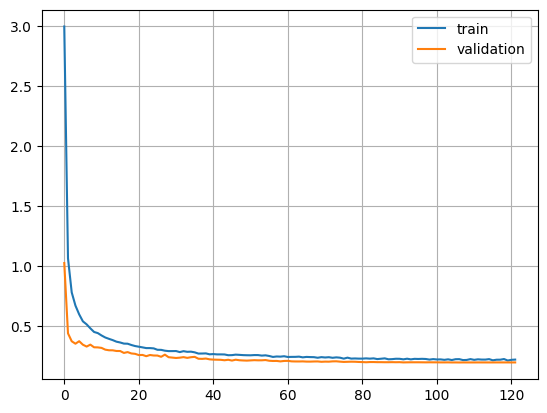

In [ ]:
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validierung")
plt.legend()
plt.grid()
plt.show()